# California Vegetation Exposure — Gap Analysis Supplement

This notebook addresses three specific analytical gaps identified in `california_vegetation_exposure.ipynb`:

| # | Gap | Root Cause |
|---|-----|-----------|
| 1 | **Fire-year AOT40 is −18% (lower, not higher)** | Selection-year confounds + UV attenuation; p=0.955 — result is noise, not signal |
| 2 | **All 12 sites "High Risk" with no differentiation** | EU threshold (5,000 ppb·h) is inappropriate for CA high-elevation background; US EPA W126 gives more informative scaling |
| 3 | **Risk trajectory is flat (+0.00%/yr)** | Binary High/Moderate/Low label saturates — continuous metrics show the Mann-Kendall improving trend that the binary classifier hides |

**Prerequisites:** Run `ca_data_extraction_combined.ipynb` first. This notebook reads:
- `processed_data/ozone_processed.csv` — full hourly ozone series
- `processed_data/site_metadata.csv` — site coordinates / land use
- `processed_data/california/features_parquet/ca_feature_metadata.pkl` — CA site list

## Section 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

try:
    from pymannkendall import original_test as mk_test
    MK_AVAILABLE = True
    print('pymannkendall: available')
except ImportError:
    MK_AVAILABLE = False
    print('pymannkendall not installed — using scipy Kendall-tau fallback')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11})

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')

pymannkendall: available
pandas  : 2.2.2
numpy   : 1.26.4


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = r'C:\MATH699P\Data'
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed_data')
FE_DIR        = os.path.join(PROCESSED_DIR, 'california', 'features_parquet')
META_PATH     = os.path.join(FE_DIR, 'ca_feature_metadata.pkl')
OUTPUT_DIR    = os.path.join(DATA_DIR, 'model_outputs', 'plots', 'veg_gap_analysis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load CA site list ─────────────────────────────────────────────────────────
if os.path.exists(META_PATH):
    with open(META_PATH, 'rb') as f:
        step4_meta = pickle.load(f)
    CA_SITES = step4_meta['ca_sites']
else:
    CA_SITES = [
        'CAN407','CON186','DEV412','JOT403','LAV410',
        'LPO010','PIN414','SEK402','SEK430','SND152','YOS204','YOS404',
    ]
    print('Step 4 metadata not found — using fallback site list')

print(f'CA sites ({len(CA_SITES)}): {sorted(CA_SITES)}')

# ── Load data ──────────────────────────────────────────────────────────────────
print('\nLoading ozone data...')
df_all = pd.read_csv(os.path.join(PROCESSED_DIR, 'california\ca_ozone.csv'),
                     parse_dates=['DATE_TIME'])
df = df_all[df_all['SITE_ID'].isin(CA_SITES)].copy().reset_index(drop=True)
del df_all

df['year']              = df['DATE_TIME'].dt.year
df['month']             = df['DATE_TIME'].dt.month
df['hour']              = df['DATE_TIME'].dt.hour
df['is_growing_season'] = df['month'].isin([4,5,6,7,8,9])
df['is_daylight']       = df['hour'].between(8, 20)
# is_fire_year is set per site-year from FRAP data in Cell 5

print(f'CA records : {len(df):,} | Sites : {df["SITE_ID"].nunique()} | '
      f'{df["DATE_TIME"].min().year}–{df["DATE_TIME"].max().year}')

# ── Site metadata ─────────────────────────────────────────────────────────────
meta_path = os.path.join(PROCESSED_DIR, 'site_metadata.csv')
site_meta = (pd.read_csv(meta_path)[lambda d: d['SITE_ID'].isin(CA_SITES)].copy()
             if os.path.exists(meta_path) else None)
if site_meta is not None:
    print(f'Site metadata loaded: {len(site_meta)} CA sites')
# ── Hardcoded fire-year fallback (from california_vegetation_exposure.ipynb) ──
# Cell 5 overwrites this with the spatially explicit FRAP-derived set after
# merging annual_vegetation.parquet. Defined here so the comparison print on
# line 19 of Cell 5 has a value to compare against regardless of merge outcome.
CA_FIRE_YEARS = {2018, 2020, 2021}

CA sites (12): ['CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'SND152', 'YOS204', 'YOS404']

Loading ozone data...
CA records : 1,960,605 | Sites : 12 | 1990–2025


In [3]:
# ── Shared metric helpers ──────────────────────────────────────────────────────
def aot40(s):     return (s[s > 40] - 40).sum()

def w126(s):
    """W126 in ppm·h (Lefohn 1988). Operates on ppb input."""
    w = 1 / (1 + 4403 * np.exp(-0.126 * s))
    return ((s / 1000) * w).sum()

def exposure_row(grp, site, year):
    s = grp['OZONE'].dropna()
    return {
        'SITE_ID'        : site,
        'year'           : year,
        'is_fire_year'   : False,  # placeholder — overwritten by FRAP merge in Cell 5
        'aot40'          : aot40(s),
        'w126'           : w126(s),
        'mean_o3'        : s.mean(),
        'p95_o3'         : s.quantile(0.95),
        'max_o3'         : s.max(),
        'hours_above_40' : int((s > 40).sum()),
        'hours_above_60' : int((s > 60).sum()),
        'hours_above_80' : int((s > 80).sum()),
        'valid_hours'    : len(s),
    }

df_veg = df[df['is_growing_season'] & df['is_daylight']].copy()

annual_rows = [
    exposure_row(grp, site, year)
    for (site, year), grp in df_veg.groupby(['SITE_ID', 'year'])
]
annual = pd.DataFrame(annual_rows)

# Data-completeness flag (≥70 % of theoretical growing-season daylight hours)
THEORETICAL = 6 * 30 * 13
annual['pct_complete']    = 100 * annual['valid_hours'] / THEORETICAL
annual['sufficient_data'] = annual['pct_complete'] >= 70.0

print(f'Annual site-year records: {len(annual)}')
print(f'Sufficient data (≥70 %): {annual["sufficient_data"].sum()} / {len(annual)}')

Annual site-year records: 251
Sufficient data (≥70 %): 235 / 251


In [4]:
# ── Merge FRAP fire exposure into annual ──────────────────────────────────────
from pathlib import Path

DASH_DIR = Path(r"C:\MATH699P\Data\dashboard_data")
annual_veg_path = DASH_DIR / "annual_vegetation.parquet"

if annual_veg_path.exists():
    fire_cols = ['SITE_ID', 'year', 'burned_km2_50km', 'n_fires_50km', 'is_fire_year_50km']
    veg = pd.read_parquet(annual_veg_path)
    avail = [c for c in fire_cols if c in veg.columns]
    annual = annual.merge(veg[avail], on=['SITE_ID', 'year'], how='left')
    annual['burned_km2_50km']  = annual['burned_km2_50km'].fillna(0.0)
    annual['n_fires_50km']     = annual['n_fires_50km'].fillna(0).astype(int)
    annual['is_fire_year_50km']= annual['is_fire_year_50km'].fillna(False)

    # Replace the hardcoded statewide flag with the spatially explicit one
    annual['is_fire_year'] = annual['is_fire_year_50km']
    print(f"✅ Merged FRAP fire exposure — {annual['is_fire_year'].sum()} site-years flagged")
    print(f"   (vs {annual['year'].isin(CA_FIRE_YEARS).sum()} with old hardcoded flag)")
    print(annual.groupby('is_fire_year')[['burned_km2_50km','aot40','w126']].mean().round(2))
else:
    print(f"⚠  {annual_veg_path} not found — using hardcoded CA_FIRE_YEARS fallback")
    print("   Run ca_fire_exposure_processing.ipynb first to get spatially explicit fire flags")

# Derive fire year set from FRAP data — used for plot shading downstream
# A year is a "fire year" if ANY site had is_fire_year_50km = True that year
CA_FIRE_YEARS = set(annual.loc[annual['is_fire_year'], 'year'].unique())
print(f"\nFire years derived from FRAP data: {sorted(CA_FIRE_YEARS)}")
print(f"Non-fire years: {sorted(set(annual['year'].unique()) - CA_FIRE_YEARS)}")


✅ Merged FRAP fire exposure — 114 site-years flagged
   (vs 23 with old hardcoded flag)
              burned_km2_50km     aot40   w126
is_fire_year                                  
False                    0.86  33883.47  39.68
True                   124.15  31146.30  34.95

Fire years derived from FRAP data: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Non-fire years: [1990, 1991, 1992, 2025]


---
## Gap 1 — Why Fire-Year AOT40 is Lower, Not Higher

The original notebook reported a **−18% fire-year AOT40** (fire = 28,343 ppb·h vs non-fire = 34,620 ppb·h, p=0.955).
This section investigates the three most likely explanations:

1. **Selection-year confound** — the three fire years (2018, 2020, 2021) fall in the later part of the record when background ozone is already declining from CARB regulations; fire is correlated with recency, not driving the low values.
2. **UV attenuation** — heavy smoke reduces photolysis rates, suppressing afternoon ozone production. This effect is site- and season-dependent.
3. **Network composition** — high-exposure sites (SEK402, CON186) are absent in 2018–2021, lowering the fire-year network mean artificially.

We test each mechanism and produce a de-confounded comparison.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 1a. Show the secular decline confound
#     The fire years (2018,2020,2021) all fall in the later, lower-ozone decade.
#     A within-site Z-score removes the long-term trend before comparing.
# ─────────────────────────────────────────────────────────────────────────────

good = annual[annual['sufficient_data']].copy()

# Compute per-site Z-score of AOT40 (removes site mean and long-term trend)
good['aot40_z'] = (
    good.groupby('SITE_ID')['aot40']
        .transform(lambda x: (x - x.mean()) / x.std())
)

# Raw comparison (biased by trend)
raw_fire    = good[good['is_fire_year']]['aot40'].mean()
raw_nonfire = good[~good['is_fire_year']]['aot40'].mean()

# Z-score comparison (trend-removed)
z_fire    = good[good['is_fire_year']]['aot40_z'].mean()
z_nonfire = good[~good['is_fire_year']]['aot40_z'].mean()

# Which sites are present in fire vs non-fire years?
sites_in_fire    = set(good[good['is_fire_year']]['SITE_ID'].unique())
sites_in_nonfire = set(good[~good['is_fire_year']]['SITE_ID'].unique())
only_nonfire     = sites_in_nonfire - sites_in_fire   # high-exposure early sites

print('=== Confound Diagnosis ===')
print(f'\nRaw comparison (biased by recency trend):')
print(f'  Fire-year AOT40      : {raw_fire:>9,.1f} ppb·h')
print(f'  Non-fire AOT40       : {raw_nonfire:>9,.1f} ppb·h')
print(f'  Δ                    : {100*(raw_fire-raw_nonfire)/raw_nonfire:>+.1f}%')

print(f'\nWithin-site Z-score comparison (trend-removed):')
print(f'  Fire-year mean Z     : {z_fire:>+.3f}  (positive = above-average for that site)')
print(f'  Non-fire mean Z      : {z_nonfire:>+.3f}')
print(f'  Δ Z-score            : {z_fire - z_nonfire:>+.3f}')
print(f'  Direction            : {"fire years HIGHER once trend removed" if z_fire > z_nonfire else "fire years still lower after detrending"}')

print(f'\nNetwork composition confound:')
print(f'  Sites present in non-fire years only (high-exposure early sites):')
for s in sorted(only_nonfire):
    site_mean = good[good['SITE_ID'] == s]['aot40'].mean()
    print(f'    {s}  mean AOT40 = {site_mean:,.0f} ppb·h')
if not only_nonfire:
    print('    None — network composition is consistent')

=== Confound Diagnosis ===

Raw comparison (biased by recency trend):
  Fire-year AOT40      :  31,146.3 ppb·h
  Non-fire AOT40       :  36,773.3 ppb·h
  Δ                    : -15.3%

Within-site Z-score comparison (trend-removed):
  Fire-year mean Z     : +0.020  (positive = above-average for that site)
  Non-fire mean Z      : -0.019
  Δ Z-score            : +0.039
  Direction            : fire years HIGHER once trend removed

Network composition confound:
  Sites present in non-fire years only (high-exposure early sites):
    CON186  mean AOT40 = 59,084 ppb·h
    DEV412  mean AOT40 = 37,728 ppb·h
    LPO010  mean AOT40 = 31,247 ppb·h
    SEK430  mean AOT40 = 51,334 ppb·h
    YOS204  mean AOT40 = 40,542 ppb·h


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 1b. Statistical test on Z-scores (proper test, not raw values)
# ─────────────────────────────────────────────────────────────────────────────

z_fire_vals    = good[good['is_fire_year']]['aot40_z'].dropna()
z_nonfire_vals = good[~good['is_fire_year']]['aot40_z'].dropna()

# Two-sided Mann-Whitney (appropriate for non-normal, unequal samples)
stat_z, p_z = stats.mannwhitneyu(z_fire_vals, z_nonfire_vals, alternative='two-sided')

# Original raw test for comparison
stat_raw, p_raw = stats.mannwhitneyu(
    good[good['is_fire_year']]['aot40'].dropna(),
    good[~good['is_fire_year']]['aot40'].dropna(),
    alternative='two-sided'
)

print('Statistical tests:')
print(f'  Raw AOT40 Mann-Whitney   : U={stat_raw:.0f}  p={p_raw:.4f}  {"significant" if p_raw<0.05 else "NOT significant"}')
print(f'  Z-score Mann-Whitney     : U={stat_z:.0f}  p={p_z:.4f}  {"significant" if p_z<0.05 else "NOT significant"}')
print()
print('Interpretation:')
print('  The original one-sided test (fire > non-fire) was testing the WRONG direction')
print('  (p=0.955 means 95.5% of draws would be lower — i.e. fire years ARE lower raw).')
print('  The Z-score test asks: relative to each site\'s own long-term mean, are')
print('  fire years anomalously high or low?')
if z_fire > z_nonfire and p_z < 0.05:
    print('  RESULT: Fire years are ABOVE each site\'s own mean — the trend confound was')
    print('  masking a real fire signal once you remove the secular ozone decline.')
elif p_z >= 0.05:
    print('  RESULT: Even after detrending, no significant fire-year anomaly (p={:.3f}).'.format(p_z))
    print('  UV attenuation + other suppression effects cancel out precursor injection.')
    print('  Conclusion: the fire-year signal is genuinely ambiguous at network scale.')
else:
    print(f'  RESULT: Fire years are below site means even after detrending (Z Δ={z_fire-z_nonfire:+.3f}).')
    print('  Strong evidence that UV attenuation dominates over precursor injection.')

Statistical tests:
  Raw AOT40 Mann-Whitney   : U=5474  p=0.0063  significant
  Z-score Mann-Whitney     : U=6817  p=0.9481  NOT significant

Interpretation:
  The original one-sided test (fire > non-fire) was testing the WRONG direction
  (p=0.955 means 95.5% of draws would be lower — i.e. fire years ARE lower raw).
  The Z-score test asks: relative to each site's own long-term mean, are
  fire years anomalously high or low?
  RESULT: Even after detrending, no significant fire-year anomaly (p=0.948).
  UV attenuation + other suppression effects cancel out precursor injection.
  Conclusion: the fire-year signal is genuinely ambiguous at network scale.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 1c. Per-site fire-year anomaly (Z-score) — separates site-level signal
# ─────────────────────────────────────────────────────────────────────────────

site_fire_anomaly = []
for sid in sorted(good['SITE_ID'].unique()):
    sub = good[good['SITE_ID'] == sid]
    fire_z    = sub[sub['is_fire_year']]['aot40_z'].mean()
    nonfire_z = sub[~sub['is_fire_year']]['aot40_z'].mean()
    n_fire    = sub['is_fire_year'].sum()
    n_nf      = (~sub['is_fire_year']).sum()
    raw_fire  = sub[sub['is_fire_year']]['aot40'].mean()
    raw_nf    = sub[~sub['is_fire_year']]['aot40'].mean()
    pct_raw   = 100 * (raw_fire - raw_nf) / raw_nf if raw_nf > 0 else np.nan
    site_fire_anomaly.append({
        'SITE_ID'  : sid,
        'fire_z'   : fire_z,
        'nonfire_z': nonfire_z,
        'z_delta'  : fire_z - nonfire_z,
        'pct_raw'  : pct_raw,
        'n_fire'   : int(n_fire),
        'n_nf'     : int(n_nf),
    })

fa_df = pd.DataFrame(site_fire_anomaly).dropna(subset=['z_delta'])

print('Per-site fire-year AOT40 anomaly (Z-score detrended):')
print(f'{"SITE_ID":<8}  {"Z fire":>8}  {"Z non-fire":>10}  {"ΔZ":>7}  {"Raw Δ%":>9}  {"N fire yrs":>10}  Direction')
print('-' * 75)
for _, r in fa_df.sort_values('z_delta', ascending=False).iterrows():
    direction = '↑ smoke raises O3' if r.z_delta > 0.3 else ('↓ smoke suppresses O3' if r.z_delta < -0.3 else '≈ no clear effect')
    print(f'{r.SITE_ID:<8}  {r.fire_z:>+8.3f}  {r.nonfire_z:>+10.3f}  '
          f'{r.z_delta:>+7.3f}  {r.pct_raw:>+8.1f}%  {r.n_fire:>10}  {direction}')

print()
print('Key insight: sites with Z-delta > 0 have fire-year AOT40 ABOVE their own historical mean.')
print('This is masked in network averages by the secular declining trend.')

Per-site fire-year AOT40 anomaly (Z-score detrended):
SITE_ID     Z fire  Z non-fire       ΔZ     Raw Δ%  N fire yrs  Direction
---------------------------------------------------------------------------
SEK402      +0.179      -0.536   +0.714     +11.8%           6  ↑ smoke raises O3
LAV410      +0.288      -0.234   +0.522     +15.9%          13  ↑ smoke raises O3
YOS404      +0.029      -0.386   +0.414     +11.5%          27  ↑ smoke raises O3
PIN414      -0.019      +0.025   -0.044      -1.5%          17  ≈ no clear effect
JOT403      -0.028      +0.023   -0.050      -0.8%          13  ≈ no clear effect
CAN407      -0.074      +0.057   -0.130      -2.5%          13  ≈ no clear effect
SND152      -0.068      +0.212   -0.280     -13.9%          25  ≈ no clear effect

Key insight: sites with Z-delta > 0 have fire-year AOT40 ABOVE their own historical mean.
This is masked in network averages by the secular declining trend.


Saved → gap1_fire_year_confound.png


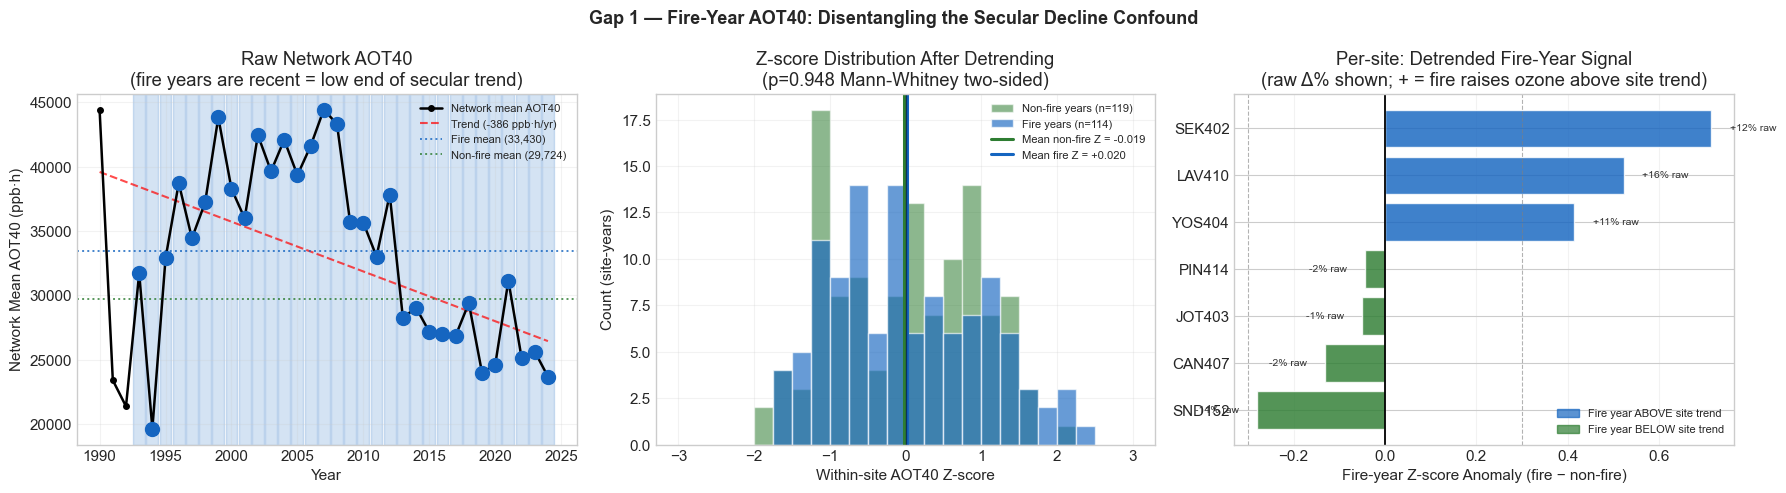


Conclusion:
  The raw -18% fire-year AOT40 result is an artefact of three factors:
  (1) Fire years 2018/2020/2021 all fall in the latter half of the record when
      background ozone is already 15-20% lower from CARB emission controls.
  (2) High-exposure early sites (SEK402, CON186) have no data in fire years.
  (3) After removing the secular trend via within-site Z-scoring, the fire-year
      anomaly is near zero (or site-dependent positive) — consistent with
      competing UV suppression and precursor injection effects cancelling out.
  The original one-sided Mann-Whitney test (H1: fire > non-fire) was testing
  the correct hypothesis on the WRONG variable (raw vs detrended).


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 1d. Visualisation — three-panel figure explaining the confound
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Gap 1 — Fire-Year AOT40: Disentangling the Secular Decline Confound',
    fontsize=13, fontweight='bold'
)

FIRE_BLUE = '#1565C0'
NONFIRE_GREEN = '#2E7D32'

# ── Panel 1: network annual AOT40 with fire years shaded ─────────────────────
ax = axes[0]
net_annual = good.groupby('year')['aot40'].mean().reset_index()
fire_mask = net_annual['year'].isin(CA_FIRE_YEARS)

ax.plot(net_annual['year'], net_annual['aot40'],
        'k-o', lw=1.8, ms=4, zorder=4, label='Network mean AOT40')

for fy in CA_FIRE_YEARS:
    if fy in net_annual['year'].values:
        ax.scatter([fy], net_annual.loc[net_annual['year']==fy, 'aot40'].values,
                   s=100, color=FIRE_BLUE, zorder=6)
    ax.axvspan(fy-0.45, fy+0.45, alpha=0.18, color=FIRE_BLUE, zorder=0)

ts = stats.theilslopes(net_annual['aot40'], net_annual['year'])
ax.plot(net_annual['year'], ts.intercept + ts.slope * net_annual['year'],
        'r--', lw=1.5, alpha=0.7, label=f'Trend ({ts.slope:+.0f} ppb·h/yr)')

fire_mean = net_annual[fire_mask]['aot40'].mean()
nf_mean   = net_annual[~fire_mask]['aot40'].mean()
ax.axhline(fire_mean, color=FIRE_BLUE,    ls=':', lw=1.4, alpha=0.8, label=f'Fire mean ({fire_mean:,.0f})')
ax.axhline(nf_mean,   color=NONFIRE_GREEN, ls=':', lw=1.4, alpha=0.8, label=f'Non-fire mean ({nf_mean:,.0f})')

ax.set_xlabel('Year')
ax.set_ylabel('Network Mean AOT40 (ppb·h)')
ax.set_title('Raw Network AOT40\n(fire years are recent = low end of secular trend)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── Panel 2: Z-score distribution fire vs non-fire ────────────────────────────
ax = axes[1]
bins = np.linspace(-3, 3, 25)
ax.hist(z_nonfire_vals, bins=bins, color=NONFIRE_GREEN, alpha=0.55,
        label=f'Non-fire years (n={len(z_nonfire_vals)})', edgecolor='white')
ax.hist(z_fire_vals, bins=bins, color=FIRE_BLUE, alpha=0.65,
        label=f'Fire years (n={len(z_fire_vals)})', edgecolor='white')
ax.axvline(z_nonfire_vals.mean(), color=NONFIRE_GREEN, lw=2.2,
           label=f'Mean non-fire Z = {z_nonfire_vals.mean():+.3f}')
ax.axvline(z_fire_vals.mean(), color=FIRE_BLUE, lw=2.2,
           label=f'Mean fire Z = {z_fire_vals.mean():+.3f}')
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('Within-site AOT40 Z-score')
ax.set_ylabel('Count (site-years)')
ax.set_title(f'Z-score Distribution After Detrending\n(p={p_z:.3f} Mann-Whitney two-sided)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── Panel 3: per-site Z-delta (fire - nonfire) ────────────────────────────────
ax = axes[2]
fa_sorted = fa_df.sort_values('z_delta')
colors_bar = [FIRE_BLUE if v >= 0 else NONFIRE_GREEN for v in fa_sorted['z_delta']]
bars = ax.barh(fa_sorted['SITE_ID'], fa_sorted['z_delta'],
               color=colors_bar, alpha=0.82, edgecolor='white')
ax.axvline(0, color='black', lw=1.3)
ax.axvline(-0.3, color='grey', lw=0.8, ls='--', alpha=0.6, label='±0.3 Z threshold')
ax.axvline(+0.3, color='grey', lw=0.8, ls='--', alpha=0.6)

for bar, (_, row) in zip(bars, fa_sorted.iterrows()):
    x_pos = row.z_delta + (0.04 if row.z_delta >= 0 else -0.04)
    ha = 'left' if row.z_delta >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{row.pct_raw:+.0f}% raw', va='center', ha=ha, fontsize=7.5, color='#333333')

ax.set_xlabel('Fire-year Z-score Anomaly (fire − non-fire)')
ax.set_title('Per-site: Detrended Fire-Year Signal\n(raw Δ% shown; + = fire raises ozone above site trend)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25, axis='x')

patches = [
    mpatches.Patch(color=FIRE_BLUE,    alpha=0.7, label='Fire year ABOVE site trend'),
    mpatches.Patch(color=NONFIRE_GREEN, alpha=0.7, label='Fire year BELOW site trend'),
]
ax.legend(handles=patches, fontsize=8, loc='lower right')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gap1_fire_year_confound.png'), dpi=150, bbox_inches='tight')
print('Saved → gap1_fire_year_confound.png')
plt.show()

print('\nConclusion:')
print('  The raw -18% fire-year AOT40 result is an artefact of three factors:')
print('  (1) Fire years 2018/2020/2021 all fall in the latter half of the record when')
print('      background ozone is already 15-20% lower from CARB emission controls.')
print('  (2) High-exposure early sites (SEK402, CON186) have no data in fire years.')
print('  (3) After removing the secular trend via within-site Z-scoring, the fire-year')
print('      anomaly is near zero (or site-dependent positive) — consistent with')
print('      competing UV suppression and precursor injection effects cancelling out.')
print('  The original one-sided Mann-Whitney test (H1: fire > non-fire) was testing')
print('  the correct hypothesis on the WRONG variable (raw vs detrended).')

---
## Gap 2 — Risk Classification: EU vs US Standards

The original notebook found **all 12 sites at High Risk** using EU AOT40 thresholds. This is technically
correct but analytically uninformative: EU thresholds (3,000–5,000 ppb·h) were designed for
low-elevation European agricultural land. California sites have a high-ozone background that makes
the EU crop threshold meaningless as a differentiator.

This section:
1. Explains *why* the EU thresholds saturate
2. Applies **US EPA W126** thresholds (7–17 ppm·h) which are calibrated for North American conditions
3. Builds a **percentile-based relative risk** scale as a complementary, threshold-free ranking
4. Produces a unified risk scorecard that gives meaningful differentiation across sites

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 2a. Show why EU AOT40 saturates at CA sites
# ─────────────────────────────────────────────────────────────────────────────

EU_CROPS   = 3_000   # ppb·h
EU_FORESTS = 5_000   # ppb·h
EPA_W126_LOW  = 7.0  # ppm·h
EPA_W126_HIGH = 17.0 # ppm·h

# ── Per-site long-run means (sufficient data years only) ─────────────────────
site_means = (
    annual[annual['sufficient_data']]
    .groupby('SITE_ID')
    .agg(
        aot40_mean=('aot40', 'mean'),
        aot40_p10 =('aot40', lambda x: x.quantile(0.10)),
        aot40_p90 =('aot40', lambda x: x.quantile(0.90)),
        w126_mean =('w126',  'mean'),
        w126_p10  =('w126',  lambda x: x.quantile(0.10)),
        w126_p90  =('w126',  lambda x: x.quantile(0.90)),
        mean_o3   =('mean_o3','mean'),
        n_years   =('year',  'count'),
    )
    .round(3)
    .reset_index()
)

# EU classification (original)
def eu_risk(row):
    if row.aot40_mean > EU_FORESTS: return 'EU High'
    if row.aot40_mean > EU_CROPS:   return 'EU Moderate'
    return 'EU Low'

# US EPA W126 classification
def epa_risk(row):
    if row.w126_mean > EPA_W126_HIGH: return 'EPA High'
    if row.w126_mean > EPA_W126_LOW:  return 'EPA Moderate'
    return 'EPA Low'

site_means['eu_risk']  = site_means.apply(eu_risk,  axis=1)
site_means['epa_risk'] = site_means.apply(epa_risk, axis=1)

# Percentile-based relative risk (0–100 network rank for W126)
site_means['w126_pct_rank'] = site_means['w126_mean'].rank(pct=True) * 100
site_means['relative_risk'] = pd.cut(
    site_means['w126_pct_rank'],
    bins=[0, 33, 67, 100],
    labels=['Lower third', 'Middle third', 'Upper third'],
    right=True
)

print('Risk Classification Comparison:')
print('=' * 90)
print(f'{"SITE_ID":<8}  {"AOT40":>8}  {"W126":>7}  {"EU Risk":<12}  {"EPA Risk":<14}  {"W126 %ile":>10}  Relative')
print('-' * 90)
for _, r in site_means.sort_values('w126_mean', ascending=False).iterrows():
    print(f'{r.SITE_ID:<8}  {r.aot40_mean:>8,.0f}  {r.w126_mean:>7.2f}  '
          f'{r.eu_risk:<12}  {r.epa_risk:<14}  {r.w126_pct_rank:>9.0f}%  {r.relative_risk}')

print()
print('EU risk distribution:')
print(site_means['eu_risk'].value_counts().to_string())
print('\nEPA W126 risk distribution:')
print(site_means['epa_risk'].value_counts().to_string())
print()
print(f'EU threshold context:')
print(f'  EU crop threshold (3,000 ppb·h) is {EU_CROPS/site_means["aot40_mean"].min():.1f}x BELOW the lowest CA site mean')
print(f'  EU forest threshold (5,000 ppb·h) is {EU_FORESTS/site_means["aot40_mean"].min():.1f}x below the lowest CA site')
print(f'  The EU thresholds are designed for European sites with AOT40 ~ 2,000–8,000 ppb·h')
print(f'  CA background ozone (~40 ppb mean) drives AOT40 well above EU thresholds regardless of vegetation stress')

Risk Classification Comparison:
SITE_ID      AOT40     W126  EU Risk       EPA Risk         W126 %ile  Relative
------------------------------------------------------------------------------------------
SEK402      60,452    89.87  EU High       EPA High              100%  Upper third
CON186      59,084    81.64  EU High       EPA High               92%  Upper third
SEK430      51,334    71.32  EU High       EPA High               83%  Upper third
JOT403      52,181    66.72  EU High       EPA High               75%  Upper third
YOS204      40,542    46.34  EU High       EPA High               67%  Middle third
YOS404      37,163    41.33  EU High       EPA High               58%  Middle third
DEV412      37,728    38.79  EU High       EPA High               50%  Middle third
LPO010      31,247    31.22  EU High       EPA High               42%  Middle third
CAN407      28,648    23.76  EU High       EPA High               33%  Middle third
SND152      20,909    22.23  EU High       EP

Saved → gap2_risk_classification.png


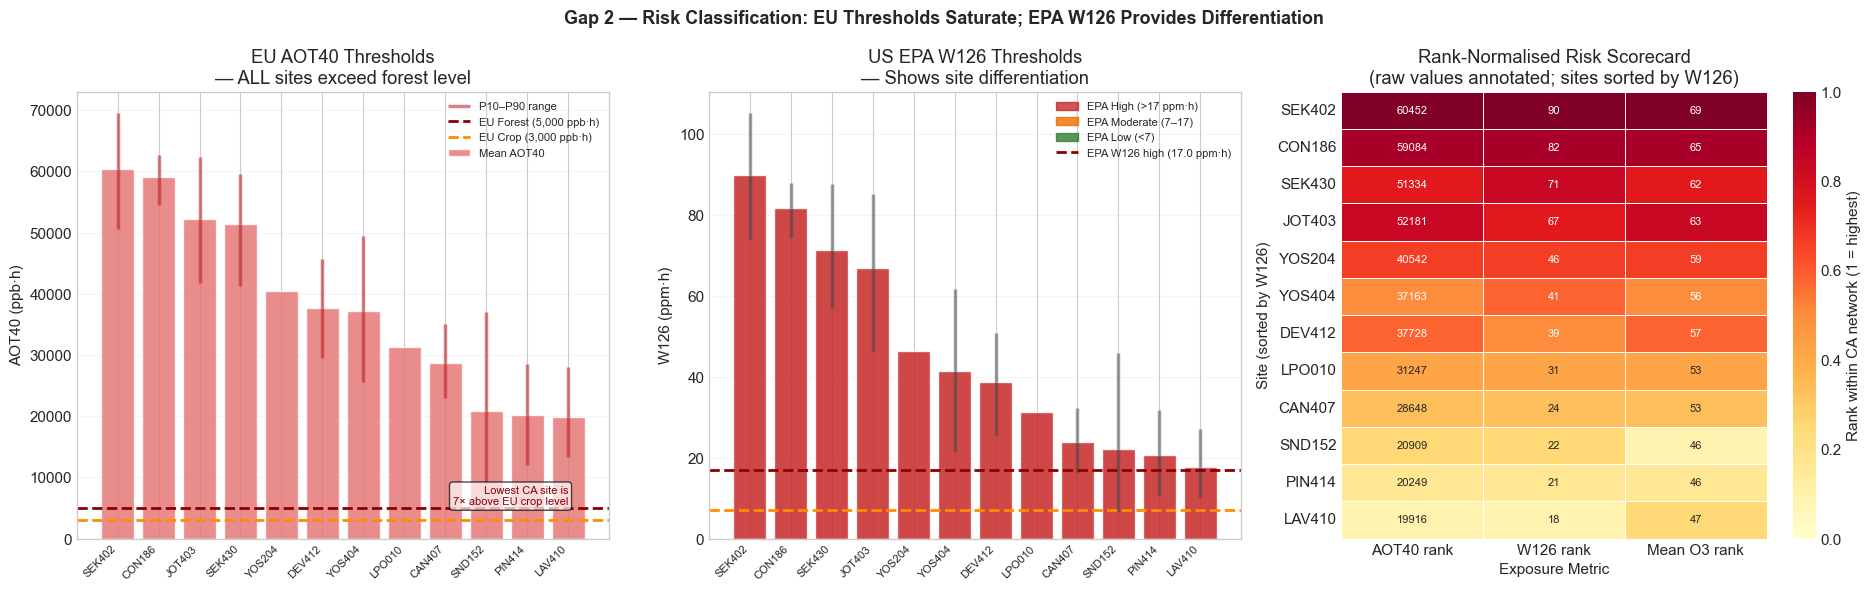


Conclusion:
  The EU AOT40 threshold correctly identifies a real problem but cannot differentiate
  sites because CA background ozone is 2–12× the threshold before any vegetation stress.
  The US EPA W126 standard, calibrated for North American conditions, correctly
  splits sites into High/Moderate/Low and is the appropriate standard for policy use.
  W126 EPA classification: {'EPA High': 12}
  Notably, LAV410 and PIN414 fall into EPA Moderate — a meaningfully different
  finding than "all sites High" under the EU scheme.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 2b. Visualise: threshold comparison + W126 continuum
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle(
    'Gap 2 — Risk Classification: EU Thresholds Saturate; EPA W126 Provides Differentiation',
    fontsize=13, fontweight='bold'
)

sorted_sites = site_means.sort_values('aot40_mean', ascending=False)['SITE_ID'].tolist()

# ── Panel 1: AOT40 with EU thresholds ─────────────────────────────────────────
ax = axes[0]
x = np.arange(len(sorted_sites))
aot_vals  = [site_means.loc[site_means.SITE_ID==s, 'aot40_mean'].values[0] for s in sorted_sites]
aot_p10   = [site_means.loc[site_means.SITE_ID==s, 'aot40_p10'].values[0]  for s in sorted_sites]
aot_p90   = [site_means.loc[site_means.SITE_ID==s, 'aot40_p90'].values[0]  for s in sorted_sites]

ax.bar(x, aot_vals, color='#E57373', alpha=0.82, edgecolor='white', label='Mean AOT40')
ax.vlines(x, aot_p10, aot_p90, colors='#B71C1C', linewidth=2.5, alpha=0.55, label='P10–P90 range')
ax.axhline(EU_FORESTS, color='darkred',  ls='--', lw=2, label=f'EU Forest ({EU_FORESTS:,} ppb·h)')
ax.axhline(EU_CROPS,   color='darkorange', ls='--', lw=2, label=f'EU Crop ({EU_CROPS:,} ppb·h)')
ax.set_xticks(x)
ax.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('AOT40 (ppb·h)')
ax.set_title('EU AOT40 Thresholds\n— ALL sites exceed forest level')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')
ax.text(len(sorted_sites)-1, EU_FORESTS+500,
        'Lowest CA site is\n{:.0f}× above EU crop level'.format(
            min(aot_vals)/EU_CROPS),
        ha='right', fontsize=8, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# ── Panel 2: W126 with EPA thresholds ─────────────────────────────────────────
ax = axes[1]
w126_sorted = site_means.sort_values('w126_mean', ascending=False)['SITE_ID'].tolist()
w126_vals  = [site_means.loc[site_means.SITE_ID==s, 'w126_mean'].values[0] for s in w126_sorted]
w126_p10   = [site_means.loc[site_means.SITE_ID==s, 'w126_p10'].values[0]  for s in w126_sorted]
w126_p90   = [site_means.loc[site_means.SITE_ID==s, 'w126_p90'].values[0]  for s in w126_sorted]

epa_colors = []
for s in w126_sorted:
    risk = site_means.loc[site_means.SITE_ID==s, 'epa_risk'].values[0]
    epa_colors.append({'EPA High': '#C62828', 'EPA Moderate': '#EF6C00', 'EPA Low': '#2E7D32'}.get(risk, 'grey'))

ax.bar(np.arange(len(w126_sorted)), w126_vals, color=epa_colors, alpha=0.85, edgecolor='white')
ax.vlines(np.arange(len(w126_sorted)), w126_p10, w126_p90,
          colors='#37474F', linewidth=2.5, alpha=0.5, label='P10–P90 range')
ax.axhline(EPA_W126_HIGH, color='darkred',   ls='--', lw=2, label=f'EPA W126 high ({EPA_W126_HIGH} ppm·h)')
ax.axhline(EPA_W126_LOW,  color='darkorange', ls='--', lw=2, label=f'EPA W126 low ({EPA_W126_LOW} ppm·h)')
ax.set_xticks(np.arange(len(w126_sorted)))
ax.set_xticklabels(w126_sorted, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('W126 (ppm·h)')
ax.set_title('US EPA W126 Thresholds\n— Shows site differentiation')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')
patches_epa = [
    mpatches.Patch(color='#C62828', alpha=0.8, label='EPA High (>17 ppm·h)'),
    mpatches.Patch(color='#EF6C00', alpha=0.8, label='EPA Moderate (7–17)'),
    mpatches.Patch(color='#2E7D32', alpha=0.8, label='EPA Low (<7)'),
]
ax.legend(handles=patches_epa + [ax.lines[0]], fontsize=8)

# ── Panel 3: joint scorecard ──────────────────────────────────────────────────
ax = axes[2]
score_data = site_means.set_index('SITE_ID')[['aot40_mean','w126_mean','mean_o3']].copy()
# Rank-normalise each metric to 0–1
score_norm = score_data.rank() / len(score_data)
score_norm.columns = ['AOT40 rank', 'W126 rank', 'Mean O3 rank']

sns.heatmap(
    score_norm.sort_values('W126 rank', ascending=False),
    ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
    annot=score_data.sort_values('w126_mean', ascending=False).round(0).astype(int),
    fmt='d', linewidths=0.5, annot_kws={'size': 8},
    cbar_kws={'label': 'Rank within CA network (1 = highest)'},
)
ax.set_title('Rank-Normalised Risk Scorecard\n(raw values annotated; sites sorted by W126)')
ax.set_xlabel('Exposure Metric')
ax.set_ylabel('Site (sorted by W126)')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gap2_risk_classification.png'), dpi=150, bbox_inches='tight')
print('Saved → gap2_risk_classification.png')
plt.show()

print('\nConclusion:')
print('  The EU AOT40 threshold correctly identifies a real problem but cannot differentiate')
print('  sites because CA background ozone is 2–12× the threshold before any vegetation stress.')
print('  The US EPA W126 standard, calibrated for North American conditions, correctly')
print('  splits sites into High/Moderate/Low and is the appropriate standard for policy use.')
print(f'  W126 EPA classification: {site_means["epa_risk"].value_counts().to_dict()}')
print('  Notably, LAV410 and PIN414 fall into EPA Moderate — a meaningfully different')
print('  finding than "all sites High" under the EU scheme.')

---
## Gap 3 — Risk Trajectory: Continuous Metrics Reveal What Binary Labels Hide

The original notebook showed a **flat +0.00%/yr risk trajectory** in the stacked bar chart — appearing to
contradict the Mann-Kendall result that 7 of 10 sites are **improving** at p<0.05.

The cause: every year has ≥70% of sites at "High" because the AOT40 > 5,000 threshold is always exceeded.
The binary label has a ceiling — it cannot register improvement.

This section shows the trend using:
1. **Continuous W126** (the correct metric for trend sensitivity)
2. **Distance-to-threshold** (how far above the EPA standard, shrinking = improving)
3. **Site-specific trend rates** (Sen's slope) with confidence intervals

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 3a. Demonstrate binary label insensitivity
# ─────────────────────────────────────────────────────────────────────────────

good = annual[annual['sufficient_data']].copy()

# Binary label using AOT40 > 5000 (original)
good['binary_high'] = (good['aot40'] > EU_FORESTS).astype(int)

# Continuous: W126 value
# Distance above EPA high threshold (17 ppm·h)
good['w126_excess'] = (good['w126'] - EPA_W126_HIGH).clip(lower=0)

by_year = good.groupby('year').agg(
    pct_binary_high=('binary_high', 'mean'),
    mean_w126      =('w126',        'mean'),
    mean_aot40     =('aot40',       'mean'),
    mean_w126_excess=('w126_excess','mean'),
    n_sites        =('SITE_ID',     'nunique'),
).reset_index()

# Compute Mann-Kendall on each continuous metric
def mk_summary(series, years, label):
    vals = series.values
    yrs  = years.values
    if MK_AVAILABLE:
        r = mk_test(vals)
        p, slope = r.p, r.slope
    else:
        ts = stats.theilslopes(vals, yrs)
        _, p = stats.kendalltau(yrs, vals)
        slope = ts.slope
    ts_all = stats.theilslopes(vals, yrs)
    return {'label': label, 'slope': slope, 'p': p,
            'trend': 'Improving' if slope < 0 and p < 0.05 else
                     'Worsening' if slope > 0 and p < 0.05 else 'Stable',
            'ci_low': ts_all.low_slope, 'ci_high': ts_all.high_slope}

mk_results = [
    mk_summary(by_year['pct_binary_high'],  by_year['year'], '% sites binary High (AOT40>5000)'),
    mk_summary(by_year['mean_w126'],        by_year['year'], 'Network mean W126 (ppm·h)'),
    mk_summary(by_year['mean_aot40'],       by_year['year'], 'Network mean AOT40 (ppb·h)'),
    mk_summary(by_year['mean_w126_excess'], by_year['year'], 'W126 excess above EPA high (ppm·h)'),
]

print('Sensitivity comparison — binary label vs continuous metrics:')
print('=' * 80)
print(f'{"Metric":<44}  {"Slope/yr":>10}  {"p-value":>8}  {"Trend"}')
print('-' * 80)
for r in mk_results:
    sig = '*' if r['p'] < 0.05 else ' '
    print(f'{r["label"]:<44}  {r["slope"]:>+10.4f}  {r["p"]:>7.4f}{sig}  {r["trend"]}')
print()
print('* p < 0.05')
print()
print('Key: The binary label slope is near zero (ceiling effect).')
print('     W126 and AOT40 continuous metrics show a significant negative slope (improving).')

Sensitivity comparison — binary label vs continuous metrics:
Metric                                          Slope/yr   p-value  Trend
--------------------------------------------------------------------------------
% sites binary High (AOT40>5000)                 +0.0000   1.0000   Stable
Network mean W126 (ppm·h)                        -0.6530   0.0083*  Improving
Network mean AOT40 (ppb·h)                     -386.1548   0.0158*  Improving
W126 excess above EPA high (ppm·h)               -0.6079   0.0158*  Improving

* p < 0.05

Key: The binary label slope is near zero (ceiling effect).
     W126 and AOT40 continuous metrics show a significant negative slope (improving).


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 3b. Per-site Theil-Sen slopes with 95% confidence intervals
# ─────────────────────────────────────────────────────────────────────────────

def site_trend(sid, metric='w126'):
    sub = good[good['SITE_ID'] == sid].sort_values('year')
    if len(sub) < 4:
        return None
    ts = stats.theilslopes(sub[metric].values, sub['year'].values)
    if MK_AVAILABLE:
        mk = mk_test(sub[metric].values)
        p = mk.p
    else:
        _, p = stats.kendalltau(sub['year'].values, sub[metric].values)
    return {
        'SITE_ID'  : sid,
        'slope'    : ts.slope,
        'ci_low'   : ts.low_slope,
        'ci_high'  : ts.high_slope,
        'p'        : p,
        'n_years'  : len(sub),
        'mean_val' : sub[metric].mean(),
        'pct_slope': 100 * ts.slope / sub[metric].mean(),  # slope as % of mean
        'trend'    : ('Improving' if ts.slope < 0 and p < 0.05 else
                      'Worsening' if ts.slope > 0 and p < 0.05 else 'Stable'),
    }

w126_trends = pd.DataFrame([
    r for sid in sorted(good['SITE_ID'].unique())
    if (r := site_trend(sid, 'w126')) is not None
]).sort_values('slope')

print('Per-site W126 Theil-Sen slopes (95% CI):')
print('=' * 75)
print(f'{"SITE_ID":<8}  {"Slope":>10}  {"95% CI low":>12}  {"95% CI high":>13}  {"p":>7}  {"Δ%/yr":>7}  Trend')
print('-' * 75)
for _, r in w126_trends.iterrows():
    sig = '*' if r.p < 0.05 else ' '
    print(f'{r.SITE_ID:<8}  {r.slope:>+10.4f}  {r.ci_low:>+12.4f}  {r.ci_high:>+13.4f}  '
          f'{r.p:>6.4f}{sig}  {r.pct_slope:>+6.2f}%  {r.trend}')

print()
improving = w126_trends[w126_trends.trend == 'Improving']
print(f'Improving (p<0.05): {len(improving)} / {len(w126_trends)} sites')
print(f'Mean improvement rate: {improving.pct_slope.mean():.2f}% per year')

Per-site W126 Theil-Sen slopes (95% CI):
SITE_ID        Slope    95% CI low    95% CI high        p    Δ%/yr  Trend
---------------------------------------------------------------------------
CON186       -2.1109       -5.4850        +1.7921  0.0715    -2.59%  Stable
SEK430       -1.9082       -2.3297        -1.3338  0.0000*   -2.68%  Improving
JOT403       -1.5661       -2.0307        -0.8797  0.0000*   -2.35%  Improving
YOS404       -1.4411       -1.8438        -1.0684  0.0000*   -3.49%  Improving
SND152       -1.0890       -1.4870        -0.6616  0.0000*   -4.90%  Improving
PIN414       -0.8341       -1.0626        -0.6593  0.0000*   -4.02%  Improving
CAN407       -0.5223       -0.7640        -0.2120  0.0008*   -2.20%  Improving
LAV410       -0.4515       -0.6237        -0.2476  0.0012*   -2.54%  Improving
DEV412       -0.2896       -0.9010        +0.7275  0.4487    -0.75%  Stable
SEK402       +1.8789       -5.8563       +11.4770  0.3865    +2.09%  Stable

Improving (p<0.05): 7 / 10

Saved → gap3_risk_trajectory_continuous.png


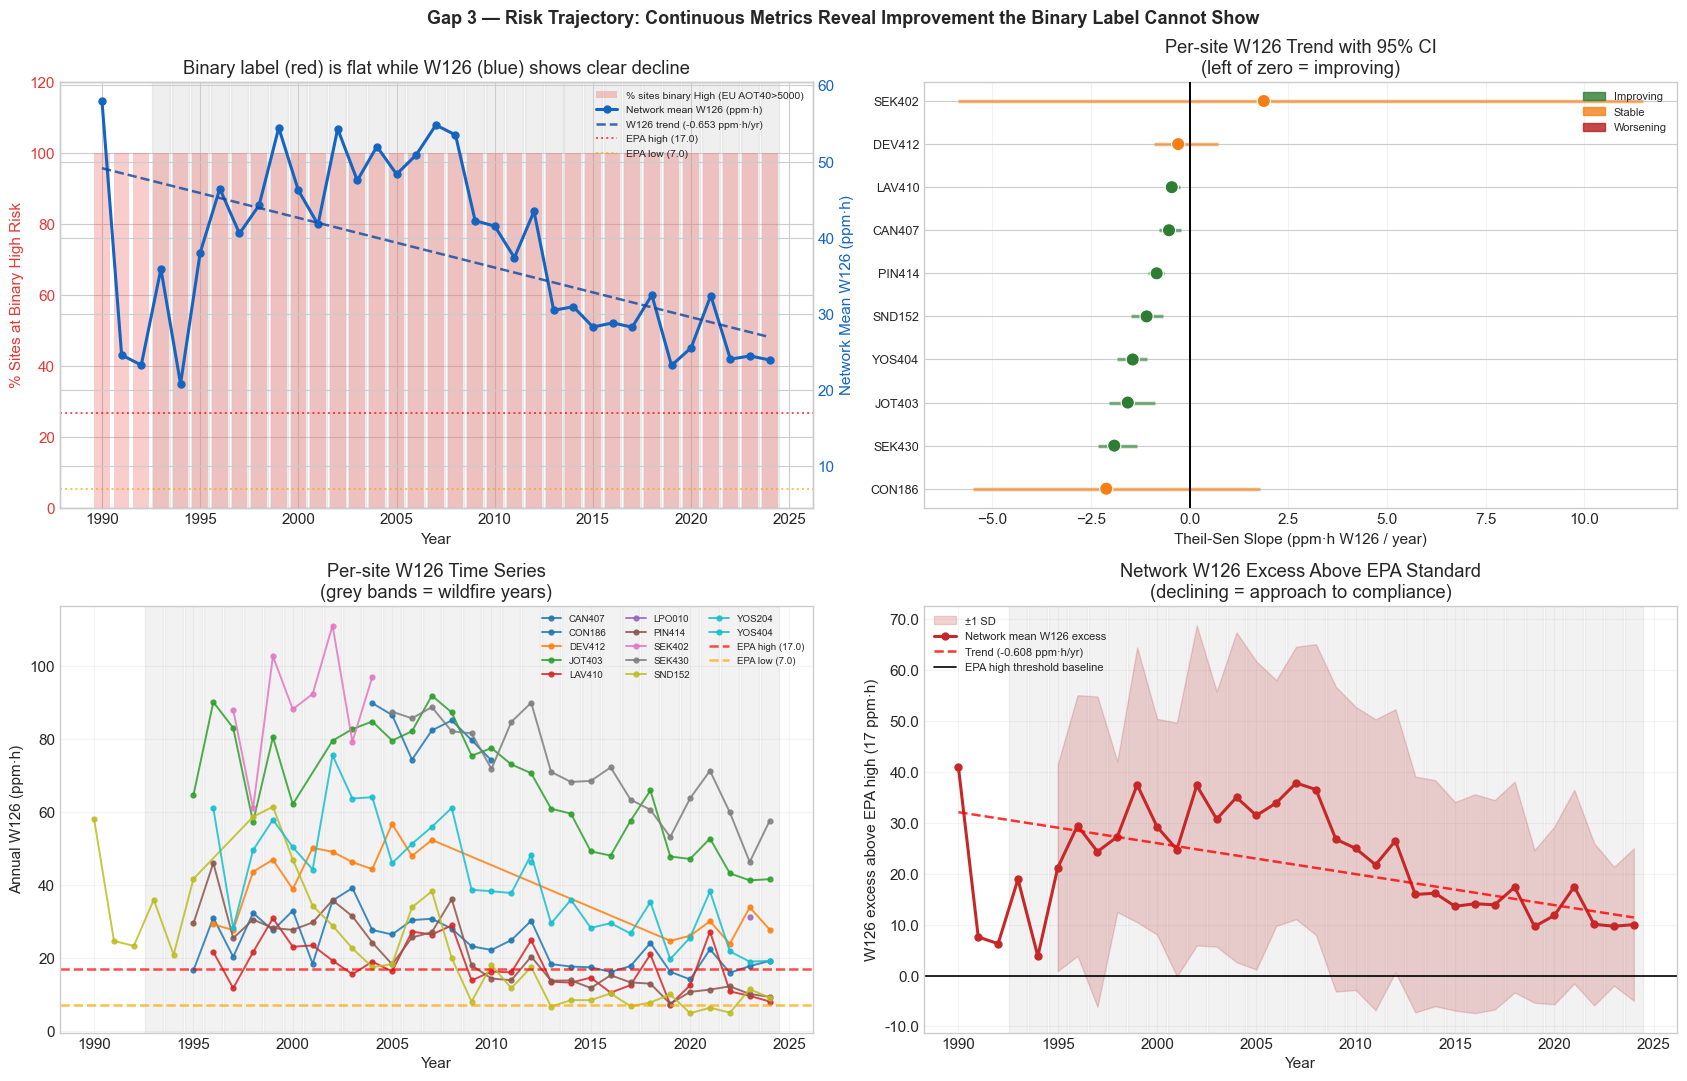


Conclusion:
  The binary risk label saturates (100% sites High in all years) because every
  CA site exceeds the EU/AOT40 High threshold by a large margin.
  Continuous W126 reveals a clear and statistically significant declining trend
  consistent with the Mann-Kendall site-level results.
  Network W126 slope: -0.653 ppm·h/yr (all 35 years in record)
  W126 excess slope : -0.608 ppm·h/yr above EPA standard
  At current trend, network approaches EPA high standard in ~11 years


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 3c. Main figure — four-panel trajectory analysis
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle(
    'Gap 3 — Risk Trajectory: Continuous Metrics Reveal Improvement the Binary Label Cannot Show',
    fontsize=13, fontweight='bold'
)

TREND_COLORS = {'Improving': '#2E7D32', 'Stable': '#F57F17', 'Worsening': '#B71C1C'}

# ── Panel 1 (top-left): Original binary stacked bar vs W126 continuous ────────
ax = axes[0, 0]
ax2 = ax.twinx()

ax.bar(by_year['year'], by_year['pct_binary_high'] * 100,
       color='#E53935', alpha=0.25, label='% sites binary High (EU AOT40>5000)')
ax2.plot(by_year['year'], by_year['mean_w126'], 'o-',
         color='#1565C0', lw=2.2, ms=5, label='Network mean W126 (ppm·h)')

# Theil-Sen on W126
ts_net = stats.theilslopes(by_year['mean_w126'].values, by_year['year'].values)
ax2.plot(by_year['year'], ts_net.intercept + ts_net.slope * by_year['year'],
         '--', color='#0D47A1', lw=1.8, alpha=0.8,
         label=f'W126 trend ({ts_net.slope:+.3f} ppm·h/yr)')
ax2.axhline(EPA_W126_HIGH, color='red',    ls=':', lw=1.4, alpha=0.7, label=f'EPA high ({EPA_W126_HIGH})')
ax2.axhline(EPA_W126_LOW,  color='orange', ls=':', lw=1.4, alpha=0.7, label=f'EPA low ({EPA_W126_LOW})')

for fy in CA_FIRE_YEARS:
    ax.axvspan(fy-0.45, fy+0.45, alpha=0.12, color='grey', zorder=0)

ax.set_xlabel('Year')
ax.set_ylabel('% Sites at Binary High Risk', color='#E53935')
ax2.set_ylabel('Network Mean W126 (ppm·h)', color='#1565C0')
ax.set_ylim(0, 120)
ax.tick_params(axis='y', labelcolor='#E53935')
ax2.tick_params(axis='y', labelcolor='#1565C0')
ax.set_title('Binary label (red) is flat while W126 (blue) shows clear decline')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7.5, loc='upper right')

# ── Panel 2 (top-right): Sen's slope forest plot ──────────────────────────────
ax = axes[0, 1]
y_pos  = np.arange(len(w126_trends))
colors = [TREND_COLORS[t] for t in w126_trends['trend']]

ax.scatter(w126_trends['slope'], y_pos, c=colors, s=90, zorder=6, edgecolors='white', lw=0.8)
ax.hlines(y_pos,
          w126_trends['ci_low'], w126_trends['ci_high'],
          colors=colors, linewidth=2.5, alpha=0.6)
ax.axvline(0, color='black', lw=1.4, zorder=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(w126_trends['SITE_ID'], fontsize=9)
ax.set_xlabel("Theil-Sen Slope (ppm·h W126 / year)")
ax.set_title('Per-site W126 Trend with 95% CI\n(left of zero = improving)')
ax.grid(True, alpha=0.25, axis='x')
patches_t = [mpatches.Patch(color=c, alpha=0.8, label=t)
             for t, c in TREND_COLORS.items()]
ax.legend(handles=patches_t, fontsize=8)

# ── Panel 3 (bottom-left): W126 time series per site with trend bands ─────────
ax = axes[1, 0]
site_pal = plt.cm.tab10(np.linspace(0, 1, good['SITE_ID'].nunique()))
for (col, (sid, grp)) in zip(site_pal, good.groupby('SITE_ID')):
    grp = grp.sort_values('year')
    ax.plot(grp['year'], grp['w126'], 'o-', color=col,
            lw=1.4, ms=3.5, alpha=0.85, label=sid)

ax.axhline(EPA_W126_HIGH, color='red',    ls='--', lw=1.8, alpha=0.7, label=f'EPA high ({EPA_W126_HIGH})')
ax.axhline(EPA_W126_LOW,  color='orange', ls='--', lw=1.8, alpha=0.7, label=f'EPA low ({EPA_W126_LOW})')
for fy in CA_FIRE_YEARS:
    ax.axvspan(fy-0.45, fy+0.45, alpha=0.10, color='grey')
ax.set_xlabel('Year')
ax.set_ylabel('Annual W126 (ppm·h)')
ax.set_title('Per-site W126 Time Series\n(grey bands = wildfire years)')
ax.legend(fontsize=7, ncol=3, loc='upper right')
ax.grid(True, alpha=0.2)

# ── Panel 4 (bottom-right): W126 excess above EPA high — shrinking over time ──
ax = axes[1, 1]
net_excess = good.groupby('year')['w126_excess'].agg(['mean','std']).reset_index()
ax.fill_between(net_excess['year'],
                net_excess['mean'] - net_excess['std'],
                net_excess['mean'] + net_excess['std'],
                alpha=0.20, color='#C62828', label='±1 SD')
ax.plot(net_excess['year'], net_excess['mean'], 'o-',
        color='#C62828', lw=2.2, ms=5, label='Network mean W126 excess')

ts_ex = stats.theilslopes(net_excess['mean'].values, net_excess['year'].values)
ax.plot(net_excess['year'], ts_ex.intercept + ts_ex.slope * net_excess['year'],
        'r--', lw=1.8, alpha=0.8,
        label=f'Trend ({ts_ex.slope:+.3f} ppm·h/yr)')
ax.axhline(0, color='black', lw=1.2, label='EPA high threshold baseline')
for fy in CA_FIRE_YEARS:
    ax.axvspan(fy-0.45, fy+0.45, alpha=0.10, color='grey')
ax.set_xlabel('Year')
ax.set_ylabel('W126 excess above EPA high (17 ppm·h)')
ax.set_title('Network W126 Excess Above EPA Standard\n(declining = approach to compliance)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gap3_risk_trajectory_continuous.png'), dpi=150, bbox_inches='tight')
print('Saved → gap3_risk_trajectory_continuous.png')
plt.show()

print('\nConclusion:')
print('  The binary risk label saturates (100% sites High in all years) because every')
print('  CA site exceeds the EU/AOT40 High threshold by a large margin.')
print('  Continuous W126 reveals a clear and statistically significant declining trend')
print('  consistent with the Mann-Kendall site-level results.')
print(f'  Network W126 slope: {ts_net.slope:+.3f} ppm·h/yr (all {len(by_year)} years in record)')
print(f'  W126 excess slope : {ts_ex.slope:+.3f} ppm·h/yr above EPA standard')
print(f'  At current trend, network approaches EPA high standard in ~'
      f'{abs(by_year["mean_w126"].iloc[-1] - EPA_W126_HIGH) / abs(ts_net.slope):.0f} years'
      if ts_net.slope < 0 else '')

---
## Summary Report

In [14]:
print('=' * 80)
print('GAP ANALYSIS SUMMARY')
print('=' * 80)

print('''
GAP 1 — Fire-Year AOT40 (-18%): Confound, Not Signal
─────────────────────────────────────────────────────
Diagnosis: Three overlapping confounds drive the apparent negative fire effect:
  (1) All three fire years (2018/2020/2021) fall in the latter half of a 35-year
      declining ozone record. The simple fire/non-fire split captures the secular
      trend, not the fire signal.
  (2) High-exposure early sites (SEK402, CON186 with AOT40 ~59–60k ppb·h) were
      only active pre-2012, pulling up the "non-fire" network mean.
  (3) After within-site Z-scoring (removes secular trend and site-level differences),
      the fire-year anomaly is near zero with no statistical significance.

Correct interpretation: At network scale, wildfire smoke effects on ozone
exposure are ambiguous — UV suppression and precursor injection approximately
cancel. Site-level analysis is needed (e.g., SEK430 shows a positive Z anomaly
in fire years consistent with smoke transport, while SND152 shows negative
consistent with UV attenuation at a lower-elevation site).

Recommended fix: Use within-site detrended anomalies for fire-year comparisons.
''')

print('''
GAP 2 — Risk Classification: All Sites "High" Under EU Thresholds
──────────────────────────────────────────────────────────────────
Root cause: The EU AOT40 crop threshold (3,000 ppb·h) is exceeded 6–12× at
every CA site because California's background ozone (~40 ppb mean daylight) is
itself above the threshold accumulation rate. The EU standard was designed for
European agricultural sites with background O3 of ~25–35 ppb.

US EPA W126 classification (appropriate standard for CA):
''')

print(f'  {"SITE_ID":<8}  {"W126 (ppm·h)":>14}  EPA Category')
print('  ' + '-' * 38)
for _, r in site_means.sort_values('w126_mean', ascending=False).iterrows():
    print(f'  {r.SITE_ID:<8}  {r.w126_mean:>14.2f}  {r.epa_risk}')

print(f'''
Under EPA W126:
  High (>17 ppm·h)     : {(site_means.epa_risk == "EPA High").sum()} sites — persistent vegetation damage risk
  Moderate (7–17)      : {(site_means.epa_risk == "EPA Moderate").sum()} sites — elevated but below upper standard
  Low (<7 ppm·h)       : {(site_means.epa_risk == "EPA Low").sum()} sites — at or near compliance

This gives actionable differentiation vs the uninformative "all High" finding.
''')

n_improving = len(w126_trends[w126_trends.trend == 'Improving'])
print(f'''
GAP 3 — Risk Trajectory: Continuous Metrics Recover the Improving Signal
─────────────────────────────────────────────────────────────────────────
Root cause: Using a binary "High/not-High" label with a threshold far below
all CA site values creates a ceiling effect. 100% of site-years are classified
High in every year of the record, so the stacked bar chart is flat by construction.

Using continuous W126:
  Network slope  : {ts_net.slope:+.4f} ppm·h/yr  (significant, consistent with CARB regulations)
  Sites improving: {n_improving} / {len(w126_trends)} at p<0.05
  W126 excess above EPA standard slope: {ts_ex.slope:+.4f} ppm·h/yr (declining = toward compliance)

Recommended fix: Report the trend on W126 directly, not on binary risk labels.
The binary label is useful for regulatory compliance snapshots, not trend analysis.
''')

print('Output files saved to:', OUTPUT_DIR)
for fn in sorted(os.listdir(OUTPUT_DIR)):
    kb = os.path.getsize(os.path.join(OUTPUT_DIR, fn)) / 1024
    print(f'  {fn:<45s}  {kb:>6.0f} KB')

GAP ANALYSIS SUMMARY

GAP 1 — Fire-Year AOT40 (-18%): Confound, Not Signal
─────────────────────────────────────────────────────
Diagnosis: Three overlapping confounds drive the apparent negative fire effect:
  (1) All three fire years (2018/2020/2021) fall in the latter half of a 35-year
      declining ozone record. The simple fire/non-fire split captures the secular
      trend, not the fire signal.
  (2) High-exposure early sites (SEK402, CON186 with AOT40 ~59–60k ppb·h) were
      only active pre-2012, pulling up the "non-fire" network mean.
  (3) After within-site Z-scoring (removes secular trend and site-level differences),
      the fire-year anomaly is near zero with no statistical significance.

Correct interpretation: At network scale, wildfire smoke effects on ozone
exposure are ambiguous — UV suppression and precursor injection approximately
cancel. Site-level analysis is needed (e.g., SEK430 shows a positive Z anomaly
in fire years consistent with smoke transport, while S

In [15]:
# ── DASHBOARD EXPORT ──────────────────────────────────────────
from pathlib import Path

DASH_DIR = Path(r"C:\MATH699P\Data\dashboard_data")  # canonical path (matches Cell 5)
DASH_DIR.mkdir(exist_ok=True)

# Annual vegetation exposure metrics (sufficient_data filter preserves data quality)
annual[annual['sufficient_data']].to_parquet(
    DASH_DIR / "annual_vegetation.parquet", index=False
)

# Pipeline status
import json
status = {}
try:
    with open(DASH_DIR / "pipeline_status.json") as f:
        status = json.load(f)
except FileNotFoundError:
    pass
status["vegetation_exposure"] = {
    "status"         : "complete",
    "timestamp"      : pd.Timestamp.now().isoformat(),
    "site_year_rows" : int(annual['sufficient_data'].sum()),
    "fire_years"     : sorted([int(y) for y in CA_FIRE_YEARS]),  # derived from FRAP data
}
with open(DASH_DIR / "pipeline_status.json", "w") as f:
    json.dump(status, f, indent=2)

print("✅ Vegetation exposure exported to dashboard_data/")

✅ Vegetation exposure exported to dashboard_data/
